# PopOut — Decision Tree AI Pipeline

This notebook covers the full decision-tree pipeline for learning to play PopOut:

1. **Dataset generation** — parallel self-play with the MCTS-Solver records (board state, best move) pairs
2. **Data exploration** — class distribution, feature overview
3. **ID3 classifier** — train on all features, inspect feature importance
4. **Feature sweep** — find the minimum number of features needed to play well
5. **Win-rate evaluation** — measure how often the tree beats FlatNumbaSolverMCTS

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.decision_tree.id3.learner import ID3Classifier
from src.decision_tree.dataset_generator import generate_dataset_parallel
from src.engine.standard.bitboard import PopOutBoard
from src.engine.standard.rules import evaluate_after_move, extended_features

plt.style.use('ggplot')
print(f'CPU cores available: {os.cpu_count()}')

CPU cores available: 16


## 1. Dataset Generation

Each worker plays one **complete game** from the empty board — both sides driven
by **FlatNumbaSolverMCTS** (full Numba JIT loop, 30–60k iter/s).  Every position
visited during the game is recorded as a `(board state, best move)` training pair.

This produces ~25–35 realistic samples per game covering opening, mid-game, and
end-game, and naturally includes the tactical positions where **pop moves** are
optimal — something random scrambling almost never generates.

The solver exits early once a position is **proven**, so most moves cost well
under the 100 000 iteration maximum.

In [2]:
N_GAMES      = 3_000   # full games to play if regenerating (~135K positions after mirroring)
ORACLE_ITERS = 100_000 # labeling oracle + opponent non-blunder strength
BLUNDER_RATE = 0.10    # probability the opponent drops to a weaker iteration count per move
DATA_PATH    = Path('../data/generated/popout_dt_dataset.csv')
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
    print(f'Loaded existing dataset: {len(df)} rows ← {DATA_PATH}')
    print('Delete the file and re-run this cell to regenerate.')
else:
    print(f'Playing {N_GAMES} games | oracle={ORACLE_ITERS:,} iter/move | blunder_rate={BLUNDER_RATE}')
    print(f'Workers: {os.cpu_count()} cores  |  Engine: FlatNumbaSolverMCTS')
    t0 = time.perf_counter()
    df = generate_dataset_parallel(
        n_games=N_GAMES,
        oracle_iterations=ORACLE_ITERS,
        blunder_rate=BLUNDER_RATE,
        seed=42,
    )
    elapsed = time.perf_counter() - t0
    df.to_csv(DATA_PATH, index=False)
    print(f'Done in {elapsed:.1f} s  |  {len(df)} positions  |  {len(df)/N_GAMES:.1f} moves/game')
    print(f'Saved → {DATA_PATH}')

print(f'\nDataset: {df.shape[0]} rows × {df.shape[1]} columns')

Playing 3000 games | oracle=100,000 iter/move | blunder_rate=0.1
Workers: 16 cores  |  Engine: FlatNumbaSolverMCTS
Done in 1518.5 s  |  119676 positions  |  39.9 moves/game
Saved → ../data/generated/popout_dt_dataset.csv

Dataset: 119676 rows × 52 columns


## 2. Data Exploration

In [3]:
TARGET       = 'best_move'
# is_proven is metadata used only for oversampling — never a tree input feature
FEATURE_COLS = [c for c in df.columns if c not in (TARGET, 'is_proven')]

print(f'Features : {len(FEATURE_COLS)}  ({FEATURE_COLS[:5]} ... {FEATURE_COLS[-1]})')
print(f'Classes  : {df[TARGET].nunique()} unique moves')
if 'is_proven' in df.columns:
    n_proven = int(df['is_proven'].sum())
    print(f'Proven positions: {n_proven} / {len(df)} ({n_proven/len(df):.1%})')
print()
df.head(3)

Features : 50  (['cell_0_0', 'cell_0_1', 'cell_0_2', 'cell_0_3', 'cell_0_4'] ... opp_wins_next)
Classes  : 14 unique moves
Proven positions: 57272 / 119676 (47.9%)



,cell_0_0,cell_0_1,cell_0_2,cell_0_3,cell_0_4,cell_0_5,cell_0_6,cell_1_0,cell_1_1,cell_1_2,...,current_player,threats_me,threats_opp,center_me,center_opp,phase,can_win,opp_wins_next,best_move,is_proven
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,drop_3,0
1,0,0,0,1,0,0,0,0,0,0,...,2,0,0,0,1,0,0,0,drop_3,0
2,0,0,0,1,0,0,0,0,0,0,...,1,0,0,1,1,0,0,0,drop_3,0


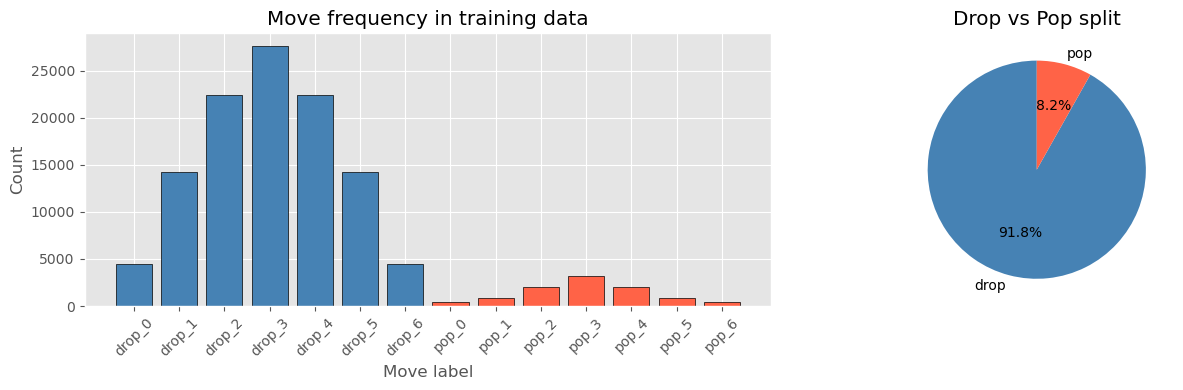

Drop moves: 109896 (91.8%)   Pop moves: 9780 (8.2%)


In [4]:
move_counts = df[TARGET].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Move frequency
colors = ['steelblue' if m.startswith('drop') else 'tomato' for m in move_counts.index]
axes[0].bar(move_counts.index, move_counts.values, color=colors, edgecolor='black')
axes[0].set_xlabel('Move label')
axes[0].set_ylabel('Count')
axes[0].set_title('Move frequency in training data')
axes[0].tick_params(axis='x', rotation=45)

# Drop vs pop split
n_drop = sum(1 for m in df[TARGET] if m.startswith('drop'))
n_pop  = len(df) - n_drop
axes[1].pie([n_drop, n_pop], labels=['drop', 'pop'], autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Drop vs Pop split')

plt.tight_layout()
plt.show()

print(f'Drop moves: {n_drop} ({n_drop/len(df):.1%})   Pop moves: {n_pop} ({n_pop/len(df):.1%})')

## 3. ID3 Classifier — Training

The board features from `to_feature_dict()` are already categorical:
- `cell_r_c` ∈ {0 = empty, 1 = player 1, 2 = player 2}  (42 features)
- `current_player` ∈ {1, 2}  (1 feature)

No discretisation step is needed — we pass them directly to `ID3Classifier`.

The dataset is split 80 / 20 for training and testing.  The model is the same
`ID3Classifier` from `src/decision_tree/id3/learner.py`.

In [5]:
OVERSAMPLE_FACTOR = 4   # proven positions are duplicated this many extra times

# Convert integer features to string so ID3Classifier groupby keys are consistent
df_str = df.copy()
for col in FEATURE_COLS:
    df_str[col] = df_str[col].astype(str)

# 80 / 20 split (stratified by move label)
df_train = df_str.sample(frac=0.8, random_state=42).reset_index(drop=True)
df_test  = df_str.drop(df_train.index).reset_index(drop=True)

# Oversample proven positions (WIN / LOSS / DRAW) so the tree prioritises
# the tactically decisive moments where the oracle's label is provably correct.
# is_proven is excluded from FEATURE_COLS so it never reaches the tree as input.
if 'is_proven' in df_train.columns:
    proven = df_train[df_train['is_proven'].astype(str) == '1']
    df_train_aug = pd.concat([df_train] + [proven] * OVERSAMPLE_FACTOR,
                             ignore_index=True)
    print(f'Proven rows: {len(proven)} ({len(proven)/len(df_train):.1%} of train)')
    print(f'After oversampling: {len(df_train_aug)} rows  '
          f'(proven share: {(len(proven)*(1+OVERSAMPLE_FACTOR))/len(df_train_aug):.1%})')
else:
    df_train_aug = df_train
    print('No is_proven column — skipping oversampling (regenerate dataset to enable).')

print(f'Train: {len(df_train)}  |  Test: {len(df_test)}')

clf_full = ID3Classifier(max_depth=10)
t0 = time.perf_counter()
clf_full.fit(df_train_aug[FEATURE_COLS + [TARGET]], target=TARGET)
train_time = time.perf_counter() - t0

train_acc = clf_full.score(df_train[FEATURE_COLS + [TARGET]], target=TARGET)
test_acc  = clf_full.score(df_test[FEATURE_COLS  + [TARGET]], target=TARGET)

print(f'Training time : {train_time:.2f} s')
print(f'Train accuracy: {train_acc:.3f}')
print(f'Test  accuracy: {test_acc:.3f}')

# Tactical accuracy breakdown
preds   = clf_full.predict(df_test[FEATURE_COLS])
correct = (preds == df_test[TARGET].astype(str))
print(f'\nTactical accuracy:')
for feat, val in [('can_win', '1'), ('opp_wins_next', '1')]:
    if feat in df_test.columns:
        mask = df_test[feat].astype(str) == val
        if mask.sum() > 0:
            print(f'  {feat}=1  (n={mask.sum():4d}): {correct[mask].mean():.3f}')
pop_mask = df_test[TARGET].str.startswith('pop')
if pop_mask.sum() > 0:
    print(f'  pop moves  (n={pop_mask.sum():4d}): {correct[pop_mask].mean():.3f}')

Proven rows: 45970 (48.0% of train)
After oversampling: 279621 rows  (proven share: 82.2%)
Train: 95741  |  Test: 23935
Training time : 187.36 s
Train accuracy: 0.854
Test  accuracy: 0.843

Tactical accuracy:
  can_win=1  (n=1179): 0.791
  opp_wins_next=1  (n=3575): 0.750
  pop moves  (n=2119): 0.894


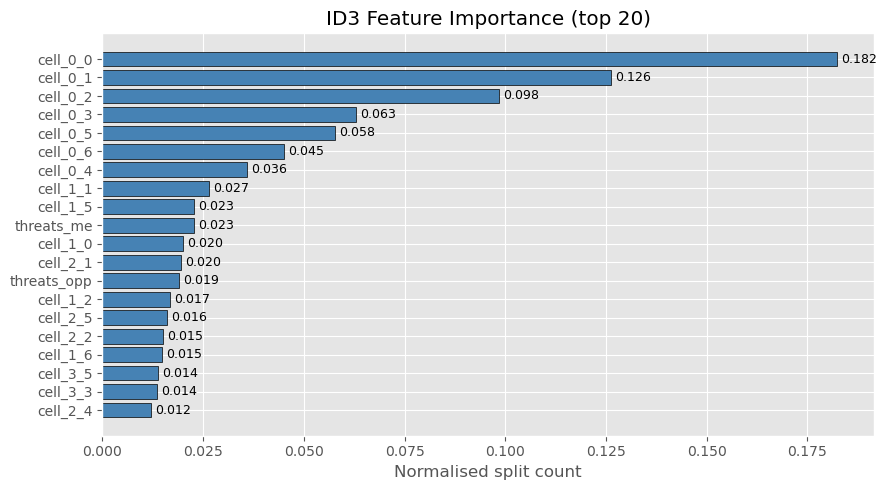

In [6]:
importance = clf_full.get_feature_importance()

# Show top 20 most-used features
top_n = 20
top_feats  = list(importance.keys())[:top_n]
top_scores = list(importance.values())[:top_n]

plt.figure(figsize=(9, 5))
bars = plt.barh(top_feats[::-1], top_scores[::-1], color='steelblue', edgecolor='black')
for bar, val in zip(bars, top_scores[::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=9)
plt.xlabel('Normalised split count')
plt.title(f'ID3 Feature Importance (top {top_n})')
plt.tight_layout()
plt.show()

## 4. Feature Sweep

We rank all features by their **information gain** on the training set, then train
separate ID3 trees using only the top-K features.  The accuracy curve reveals the
**minimum feature budget** the game requires to achieve good move prediction.

In [7]:
# Rank features by IG computed on the training set
_ranker = ID3Classifier()
ig_scores = {
    feat: _ranker.information_gain(df_train, feat, TARGET)
    for feat in FEATURE_COLS
}
ranked_features = sorted(ig_scores, key=ig_scores.get, reverse=True)

print('Top 10 features by information gain:')
for i, f in enumerate(ranked_features[:10], 1):
    print(f'  {i:2d}. {f:<18}  IG = {ig_scores[f]:.4f}')

Top 10 features by information gain:
   1. center_me           IG = 0.6927
   2. center_opp          IG = 0.6145
   3. cell_3_3            IG = 0.4637
   4. phase               IG = 0.3645
   5. cell_2_3            IG = 0.3504
   6. cell_0_2            IG = 0.3295
   7. cell_0_4            IG = 0.3293
   8. cell_1_2            IG = 0.2486
   9. cell_1_4            IG = 0.2473
  10. cell_1_3            IG = 0.2248


In [8]:
K_VALUES = [1, 3, 5, 10, 15, 20, 30, len(FEATURE_COLS)]
sweep_results = []

for k in K_VALUES:
    top_k_feats = ranked_features[:k]
    cols = top_k_feats + [TARGET]

    clf_k = ID3Classifier(max_depth=15)
    clf_k.fit(df_train[cols], target=TARGET)

    train_a = clf_k.score(df_train[cols], target=TARGET)
    test_a  = clf_k.score(df_test[cols],  target=TARGET)
    sweep_results.append({'K': k, 'Train': train_a, 'Test': test_a})
    print(f'K={k:3d}  train={train_a:.3f}  test={test_a:.3f}')

sweep_df = pd.DataFrame(sweep_results)

K=  1  train=0.399  test=0.391
K=  3  train=0.446  test=0.453
K=  5  train=0.462  test=0.469
K= 10  train=0.689  test=0.694
K= 15  train=0.781  test=0.778
K= 20  train=0.822  test=0.816
K= 30  train=0.850  test=0.841
K= 50  train=0.857  test=0.847


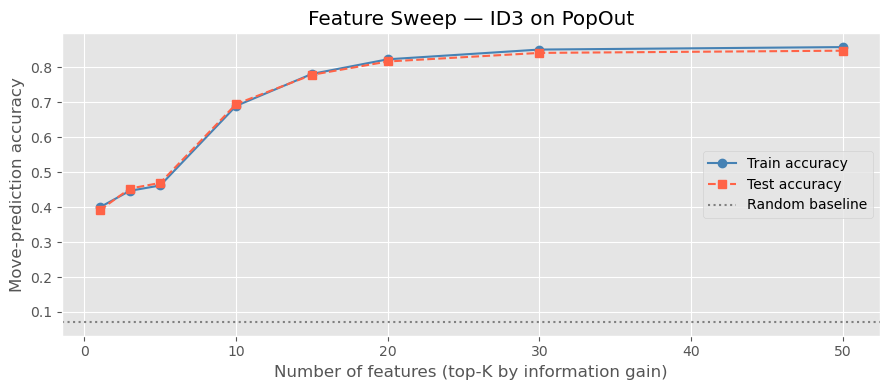

In [9]:
plt.figure(figsize=(9, 4))
plt.plot(sweep_df['K'], sweep_df['Train'], 'o-', label='Train accuracy', color='steelblue')
plt.plot(sweep_df['K'], sweep_df['Test'],  's--', label='Test accuracy',  color='tomato')
plt.axhline(1/df[TARGET].nunique(), color='gray', linestyle=':', label='Random baseline')
plt.xlabel('Number of features (top-K by information gain)')
plt.ylabel('Move-prediction accuracy')
plt.title('Feature Sweep — ID3 on PopOut')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Win-Rate Evaluation

The ID3 tree is evaluated against two engine families at multiple iteration counts:

| Engine | Iterations tested | Notes |
|---|---|---|
| **FlatNumbaMCTS** | 100 · 500 · 1 000 · 5 000 · 10 000 | Standard MCTS, no proof propagation |
| **FlatNumbaSolverMCTS** | 1 000 · 5 000 · 10 000 · 50 000 · 100 000 | MCTS-Solver, exits when proven & all root moves tried |

30 games per configuration, alternating sides for balance.
When the tree predicts an illegal move it falls back to a random legal move.

In [10]:
from src.mcts.optimized.numba_mcts import warmup, FlatNumbaMCTS
from src.mcts.optimized.numba_solver import FlatNumbaSolverMCTS

print('Warming up Numba JIT (one-time cost, ~2–5 s) ...')
t0 = time.perf_counter()
warmup()   # covers FlatNumbaMCTS, NumbaMCTS, FlatNumbaSolverMCTS and all kernels
print(f'Warmup done in {time.perf_counter() - t0:.1f} s')

Warming up Numba JIT (one-time cost, ~2–5 s) ...
Warmup done in 0.2 s


In [11]:
def _label_to_move(label: str) -> int:
    move_type, col = label.split('_')
    return int(col) if move_type == 'drop' else int(col) + 7


def tree_choose_move(clf, board):
    features = extended_features(board)
    row  = pd.Series({k: str(v) for k, v in features.items()})
    move = _label_to_move(clf.predict_one(row))
    legal = board.legal_moves()
    return move if move in legal else random.choice(legal)


def play_one_game(clf, agent, tree_plays_as, mcts_iterations, max_moves=120):
    """Play one game; returns +1 (tree wins), -1 (tree loses), 0 (draw)."""
    board = PopOutBoard()
    for _ in range(max_moves):
        legal = board.legal_moves()
        if not legal:
            return 0
        mover = board.current_player
        move  = tree_choose_move(clf, board) if mover == tree_plays_as \
                else agent.run(board, iterations=mcts_iterations)
        board.apply_move(move)
        winner = evaluate_after_move(board, mover=mover)
        if winner != 0:
            return 1 if winner == tree_plays_as else -1
    return 0

In [12]:
EVAL_GAMES = 30

CONFIGS = {
    'FlatNumbaMCTS':       [100, 500, 1_000, 5_000, 10_000],
    'FlatNumbaSolverMCTS': [1_000, 5_000, 10_000, 50_000, 100_000],
}

eval_results = {}   # (engine, iters) -> (wins, losses, draws)

t0 = time.perf_counter()
for engine_name, iter_list in CONFIGS.items():
    for iters in iter_list:
        agent = (FlatNumbaMCTS(max_nodes=iters + 256)
                 if engine_name == 'FlatNumbaMCTS'
                 else FlatNumbaSolverMCTS(max_nodes=iters + 256))

        wins = losses = draws = 0
        for i in range(EVAL_GAMES):
            r = play_one_game(clf_full, agent, 1 if i % 2 == 0 else 2, iters)
            if r == 1:    wins   += 1
            elif r == -1: losses += 1
            else:         draws  += 1

        eval_results[(engine_name, iters)] = (wins, losses, draws)
        wr = wins / EVAL_GAMES
        print(f'{engine_name:22s}  {iters:7,d} iter  →  {wr:5.1%}  ({wins}W / {losses}L / {draws}D)')

    print()

print(f'Total evaluation time: {time.perf_counter() - t0:.1f} s')

FlatNumbaMCTS               100 iter  →  33.3%  (10W / 20L / 0D)
FlatNumbaMCTS               500 iter  →  13.3%  (4W / 26L / 0D)
FlatNumbaMCTS             1,000 iter  →  13.3%  (4W / 26L / 0D)
FlatNumbaMCTS             5,000 iter  →  53.3%  (16W / 14L / 0D)
FlatNumbaMCTS            10,000 iter  →  63.3%  (19W / 11L / 0D)

FlatNumbaSolverMCTS       1,000 iter  →  23.3%  (7W / 23L / 0D)
FlatNumbaSolverMCTS       5,000 iter  →  43.3%  (13W / 17L / 0D)
FlatNumbaSolverMCTS      10,000 iter  →  50.0%  (15W / 15L / 0D)
FlatNumbaSolverMCTS      50,000 iter  →  50.0%  (15W / 15L / 0D)
FlatNumbaSolverMCTS     100,000 iter  →  56.7%  (17W / 13L / 0D)

Total evaluation time: 91.8 s


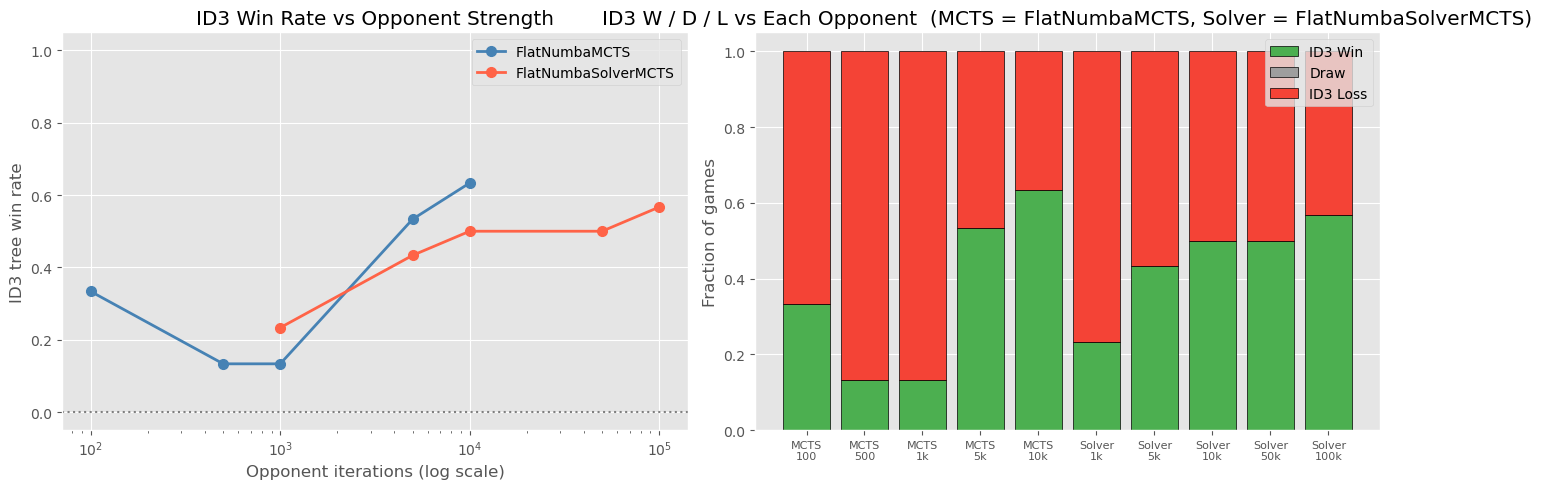


Opponent engine         Iterations   ID3 Win%   ID3 W   ID3 L    Draw
─────────────────────────────────────────────────────────────────
FlatNumbaMCTS                  100      33.3%      10      20       0
FlatNumbaMCTS                  500      13.3%       4      26       0
FlatNumbaMCTS                1,000      13.3%       4      26       0
FlatNumbaMCTS                5,000      53.3%      16      14       0
FlatNumbaMCTS               10,000      63.3%      19      11       0

FlatNumbaSolverMCTS          1,000      23.3%       7      23       0
FlatNumbaSolverMCTS          5,000      43.3%      13      17       0
FlatNumbaSolverMCTS         10,000      50.0%      15      15       0
FlatNumbaSolverMCTS         50,000      50.0%      15      15       0
FlatNumbaSolverMCTS        100,000      56.7%      17      13       0



In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ENGINE_SHORT = {'FlatNumbaMCTS': 'MCTS', 'FlatNumbaSolverMCTS': 'Solver'}
colors       = {'FlatNumbaMCTS': 'steelblue', 'FlatNumbaSolverMCTS': 'tomato'}

# Left: ID3 win rate vs opponent iterations, one line per engine family
for engine_name, iter_list in CONFIGS.items():
    win_rates = [eval_results[(engine_name, it)][0] / EVAL_GAMES for it in iter_list]
    axes[0].plot(iter_list, win_rates, 'o-',
                 label=engine_name, color=colors[engine_name], linewidth=2, markersize=7)

axes[0].set_xscale('log')
axes[0].set_xlabel('Opponent iterations (log scale)')
axes[0].set_ylabel('ID3 tree win rate')
axes[0].set_title('ID3 Win Rate vs Opponent Strength')
axes[0].set_ylim(-0.05, 1.05)
axes[0].axhline(0, color='gray', linestyle=':')
axes[0].legend()

# Right: stacked W / D / L bar chart (all from ID3's perspective)
bar_labels, bar_w, bar_d, bar_l = [], [], [], []
for engine_name, iter_list in CONFIGS.items():
    short = ENGINE_SHORT[engine_name]
    for it in iter_list:
        w, l, d = eval_results[(engine_name, it)]
        label = f'{short}\n{it//1000}k' if it >= 1000 else f'{short}\n{it}'
        bar_labels.append(label)
        bar_w.append(w / EVAL_GAMES)
        bar_d.append(d / EVAL_GAMES)
        bar_l.append(l / EVAL_GAMES)

x = range(len(bar_labels))
axes[1].bar(x, bar_w, label='ID3 Win',  color='#4CAF50', edgecolor='black')
axes[1].bar(x, bar_d, bottom=bar_w,     label='Draw',     color='#9E9E9E', edgecolor='black')
axes[1].bar(x, bar_l, bottom=[w+d for w,d in zip(bar_w, bar_d)],
            label='ID3 Loss', color='#F44336', edgecolor='black')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(bar_labels, fontsize=8)
axes[1].set_ylabel('Fraction of games')
axes[1].set_title('ID3 W / D / L vs Each Opponent  (MCTS = FlatNumbaMCTS, Solver = FlatNumbaSolverMCTS)')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# Summary table — perspective is always the ID3 tree
print(f'\n{"Opponent engine":<22}  {"Iterations":>10}  {"ID3 Win%":>9}  {"ID3 W":>6}  {"ID3 L":>6}  {"Draw":>6}')
print('─' * 65)
for engine_name, iter_list in CONFIGS.items():
    for it in iter_list:
        w, l, d = eval_results[(engine_name, it)]
        print(f'{engine_name:<22}  {it:>10,}  {w/EVAL_GAMES:>9.1%}  {w:>6}  {l:>6}  {d:>6}')
    print()